# Co to jest Machine Learning

# Czym jest wizja komputerowa

In [ ]:
!pip install -r requirements.txt

# Podsatwy Pythona

*Dlaczego python a nie np cpp.* 

## Drobne różnice z cpp 
- Nie ma średników na koniec lini
- nie ma typów (*niżej więcej*)
- nie ma `{}`, zamiast tego korzysta się z **indentacji (*taby*)**
- **Brak kompilacji** programów przed wykonaniem (*jezyk interpretowany*)

## Zmienne

Zmienne w pythonie **nie mają typów**. *Co to znaczy?*

W np. `c++` przy tworzeniu zmiennej musimy podać jej typ.
```cpp
int val = 64;
```
Gdy już stworzymy taką wartość to *nie możemy* jej zmienić:
```cpp
int val = 64;
val = "sześdziesiąt cztery"; // bład
```

In [ ]:
val = 64
print(val) # output: 64

# Dodatkowo, możemy zmieniać typ wartości
val = 64
val = "sześćdziesiąt cztery"
print(val) # output: "sześćdziesiąt cztery'

typy wartości można jendak podawać, żeby utrudnić tworzenie bugów
```py
val: int = 64
val = "sześćdziesiąt cztery" # <- nie ma błędu, ale IDE powinno to zaznaczyć (jak niżej)
```

![wrong type](images/python_linter.png)

[*dla ciekawych czemu nie trzeba typować wartości - link*](https://stackoverflow.com/questions/3781454/why-python-doesnt-need-type-declaration-for-python-other-way-what-are-the-adv)

## Wypisywanie dancyh


`print(val)` <=> `cout << val << "\n";`

Jeżeli chcemy wypisać jakąś Zmienną z opisem najpopularniejsze są `f-stringi`.

In [ ]:
val = 64
print(f"wartość val: {val}")

Można też rozdzielić przecinkiem, wtedy kolejne rzeczy wypiszą się rozdzielone spacją.

In [ ]:
print("wartość val:", val)

## Pętle

W pythonie nie ma pętli `for(int i = 0; i < n; i++)`

Możemy korzystać z `while(...)`

In [13]:
i = 0
while(i < 5):
    print(i)
    i += 1

0
1
2
3
4


Jest konstrukcja `for each`

In [ ]:
for i in range(5):
    print(i)

Możemy też iterować po elemntach listy.

In [ ]:
lista = ["raz", "dwa", "trzy", "cztery", 1] # listy mogą przechowywać różne typy danych
for i in lista:
    print(i)

raz
dwa
trzy
cztery
1


## Biblioteki

Większość funkcjonalności pythona zawiera się w zewnętrznych bibliotekach (tak jak `cin` i `cout` są z `iostream` w `c++`).

Jeżeli chodzi o bibliotekę którą będziemy używać do wizji komputerowej to jest to `ultralytics`, czyli modele ogólnie znane jako `YOLO`.

Te modele pozwalają na wszystkie podstawowe rzeczy związane z wizją komputerową, czyli **detekcje, estymacje pozycji i segmentacje**

Do wizualizacji będziemy korzystać z `PIL` oraz `opencv`

## Detekcja 

Najbardziej podstawową funkcjonalnością wizji komputerowej jest **detekcja**. Detekcja polega na rozpoznaniu obiektu na zdjęciu oraz wskazania gdzie się znajduje. 

Sprawdźmy to na zdjęciach poniżej.
![](images/baseball.jpg)

In [20]:
from ultralytics import YOLO

detect_model = YOLO("yolo26n.pt")
results_det = detect_model("images/baseball.jpg")


image 1/1 /home/maciekb/KnSpa/warsztaty/images/baseball.jpg: 640x640 3 persons, 2 baseball gloves, 177.9ms
Speed: 6.4ms preprocess, 177.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)


### Co oznacza to wyjście z konsoli? Czy ludzie zostali rozpoznani?

```txt
image 1/1 /*/images/baseball.jpg: 640x640 3 persons, 2 baseball gloves, 177.9ms
Speed: 6.4ms preprocess, 177.9ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
```


#### Pierwsza część: 

- `image 1/1`: Przetworzono pierwszy z jednego przekazanego obrazu (batch size = 1).

- `640x640`: Rozdzielczość, do której sieć przeskalowała wejściowe zdjęcie.

- `3 persons, 2 baseball gloves`: Obiekty zaklasyfikowane z pewnością wyższą niż próg (domyślnie 0.25).

- `177.9ms`: Czas wykonania obliczeń przez model na tym zdjęciu.

#### Druga część:

- `shape (1, 3, 640, 640)`: Wymiary tensora 4D (można o tym myśleć jak o 4 wymiarowej tablicy) w formacie $\text{Batch} \times \text{Channels} \times \text{Height} \times \text{Width}$. Obraz kolorowy RGB ($3$ kanały) o boku $640 \times 640$ px.
- `preprocess (6.4 ms)`: Przygotowanie danych na CPU: przeskalowanie obrazu z zachowaniem proporcji (letterboxing), konwersja kolorów BGR $\to$ RGB, normalizacja wartości pikseli z przedziału $[0, 255]$ do zmiennoprzecinkowych $[0.0, 1.0]$.
- `inference (177.9 ms)`: Przejście tensora przez miliardy wag sieci neuronowej (mnożenia macierzy). Czas 177.9 ms oznacza zaledwie:
$$
\frac{1000ms}{177.9ms} \sim 5.6fps
$$
- `**Postprocess (2.9 ms)**`: algorytm NMS (Non-Maximum Suppression), który usuwa dublujące się ramki.


### Wyświetlanie / Wizualizacja detekcji

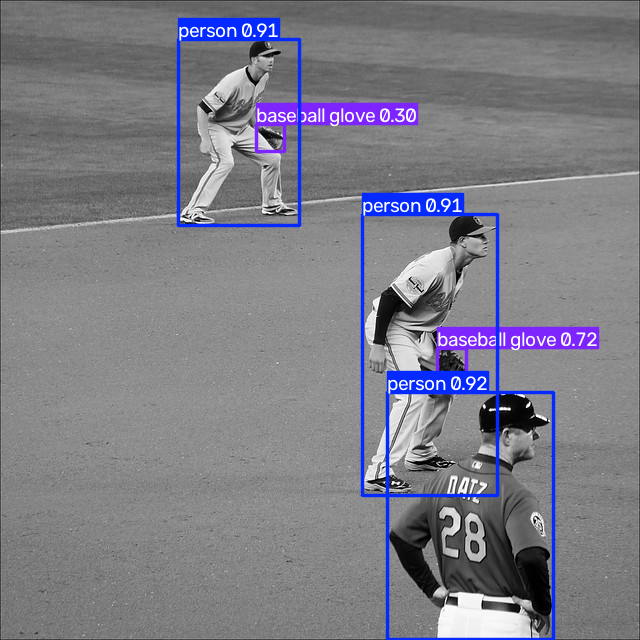

In [ ]:
import cv2
from PIL import Image

# results_det[0].plot() zwraca zmodyfikowaną macierz NumPy z narysowanymi ramkami
annotated_bgr = results_det[0].plot()

# Konwersja BGR -> RGB (OpenCV domyślnie czyta w BGR, PIL wyświetla w RGB)
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

# Wyświetlenie obrazu wprost w komórce notebooka
Image.fromarray(annotated_rgb)

### Co tak naprawdę zwrócił model? (Anatomia Bounding Boxa)

Model nie zwraca gotowego obrazka, tylko listę wykrytych ramek. Każda ramka (`box`) to:
1. **Współrzędne geometryczne** (`xyxy`: $x_{min}, y_{min}, x_{max}, y_{max}$)
2. **Prawdopodobieństwo / Pewność** (`conf` $\in [0, 1]$)
3. **Numer klasy** (`cls`) powiązany ze słownikiem etykiet

Model widzi to w poniższy sposób:

In [ ]:
boxes = results_det[0].boxes

for i, box in enumerate(boxes):
    # Wyciągamy współrzędne jako liczby całkowite
    x1, y1, x2, y2 = box.xyxy[0].tolist()
    confidence = float(box.conf[0])
    class_id = int(box.cls[0])
    class_name = detect_model.names[class_id]

    print(
        f"Obiekt {i + 1}: {class_name.upper()} | "
        f"Pewność: {confidence:.2%} | "
        f"Pozycja: [{int(x1)}, {int(y1)}, {int(x2)}, {int(y2)}]"
    )

Obiekt 1: PERSON | Pewność: 91.74% | Pozycja: [387, 392, 553, 639]
Obiekt 2: PERSON | Pewność: 91.14% | Pozycja: [362, 214, 497, 495]
Obiekt 3: PERSON | Pewność: 91.05% | Pozycja: [178, 39, 299, 225]
Obiekt 4: BASEBALL GLOVE | Pewność: 71.83% | Pozycja: [437, 348, 466, 392]
Obiekt 5: BASEBALL GLOVE | Pewność: 30.27% | Pozycja: [256, 124, 284, 151]


### Zadanie dla Ciebie: Eksperyment z parametrem `conf`

Zmień próg pewności (`conf`) w predykcji dla zdjęcia wykorzystywanego wcześniej, oraz dla dwóch pozostałych.
* Co się stanie, gdy ustawisz `conf=0.05`? (Obserwuj halucynacje i fałszywe wykrycia)
* Co się stanie, gdy ustawisz `conf=0.90`? (Które obiekty zniknęły?)

|baseball|guy_with_tie|london_xmas|restaurant|
|---|---|---|---|
|![](images/baseball.jpg)|![](images/guy_with_tie.jpg)|![](images/london_xmas.jpg)|![](images/restaurant.jpg)|

In [46]:
# Tutaj ustaw wartość progu
CONF_THRESHOLD = 0.5


0: 640x640 3 persons, 1 baseball glove, 70.0ms
1: 640x640 1 person, 1 tie, 2 cups, 70.0ms
2: 640x640 2 persons, 1 bicycle, 3 buss, 70.0ms
3: 640x640 1 person, 1 bowl, 70.0ms
Speed: 3.3ms preprocess, 70.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


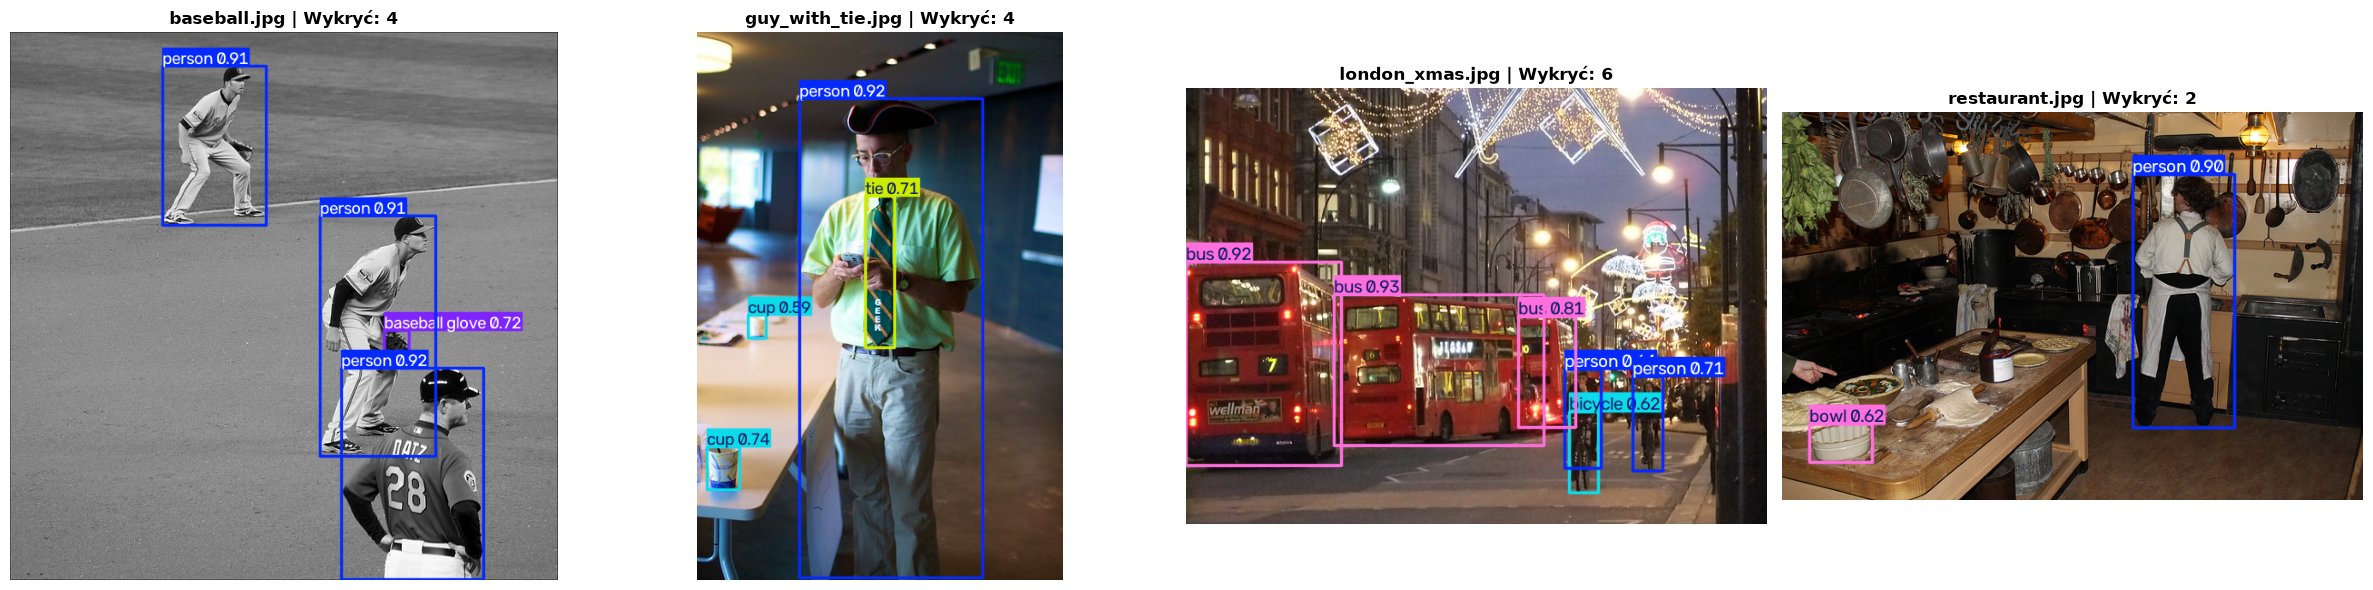

In [47]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

detect_model = YOLO("yolo26n.pt")
sciezki = [
    "images/baseball.jpg",
    "images/guy_with_tie.jpg",
    "images/london_xmas.jpg",
    "images/restaurant.jpg",
]

# 2. Uruchomienie detekcji na liście zdjęć naraz
results = detect_model(sciezki, conf=CONF_THRESHOLD)

# 3. Wyświetlenie 4 zdjęć obok siebie (1 wiersz, 4 kolumny)
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, res, sciezka in zip(axes, results, sciezki):
    # Rysowanie ramek przez YOLO i konwersja z BGR do RGB
    annotated_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)

    ax.imshow(annotated_rgb)
    nazwa_pliku = sciezka.split("/")[-1]
    ax.set_title(
        f"{nazwa_pliku} | Wykryć: {len(res.boxes)}",
        fontsize=12,
        fontweight="bold",
    )
    ax.axis("off")  # Wyłączenie osi z podziałką pikseli

plt.tight_layout()
plt.show()

# 5. Pose Estimation (Estymacja Postawy)

Detekcja obiektów odpowiadała na pytanie: *„gdzie w kadrze jest człowiek?”* (jako prostokąt).  
**Pose Estimation** idzie krok głębiej i odpowiada na pytanie: *„w jakim układzie znajduje się jego ciało?”*.

Zamiast ramki model wykrywa **punkty kluczowe (Keypoints)** – współrzędne anatomicznych stawów i elementów twarzy połączonych w szkielet.

### Sprawdź poniżej jak reprezentowane są zdjęcia
|skateboard|baseball_1guy|
|---|---|
|![](images/skateboard.jpg)|![](images/baseball_1guy.jpg)|


0: 640x640 1 person, 109.4ms
1: 640x640 4 persons, 109.4ms
Speed: 4.9ms preprocess, 109.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


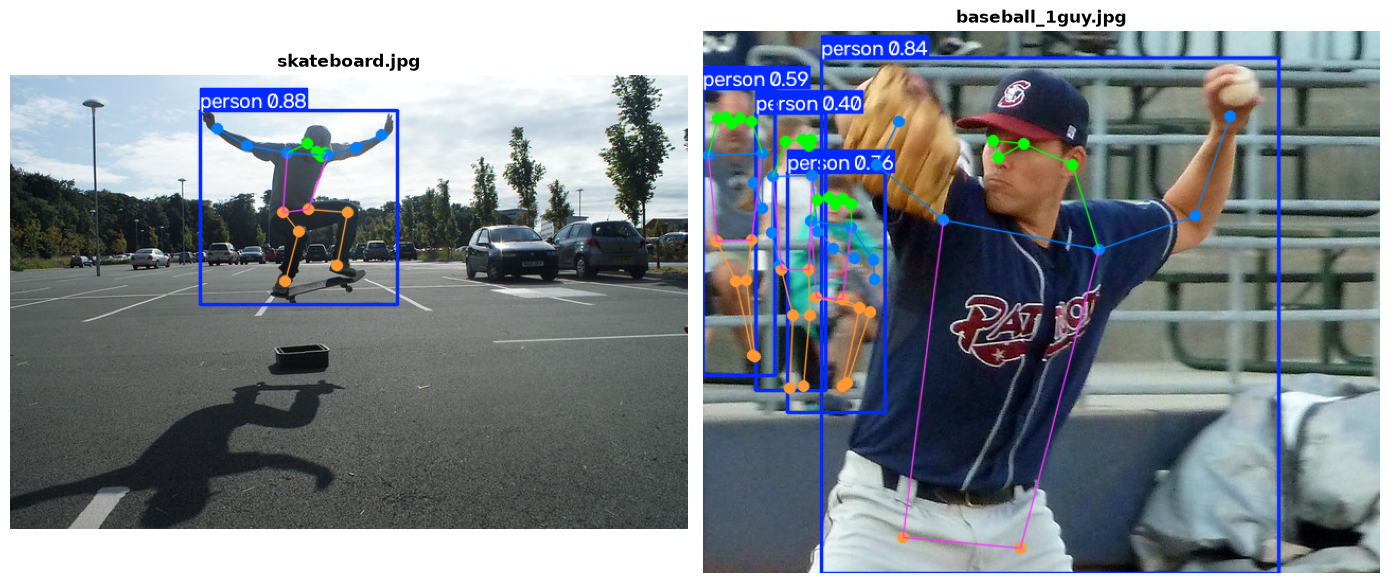

In [53]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Załadowanie modelu Pose
pose_model = YOLO("yolo26n-pose.pt")  # lub yolov8n-pose.pt

sciezki = ["images/skateboard.jpg", "images/baseball_1guy.jpg"]
results_pose = pose_model(sciezki)

# Podgląd obu szkieletów obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, res, sciezka in zip(axes, results_pose, sciezki):
    annotated_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(annotated_rgb)
    ax.set_title(sciezka.split("/")[-1], fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Jak komputer pamięta szkielet? (Format wyjścia COCO)

Model korzysta ze standardu **COCO Keypoints**, który definiuje dokładnie **17 punktów anatomicznych**:

| Indeks | Punkt | Indeks | Punkt | Indeks | Punkt |
| :---: | :--- | :---: | :--- | :---: | :--- |
| **0** | Nos (`NOSE`) | **6** | Prawy bark | **12** | Praworęczne biodro |
| **1** | Lewe oko | **7** | Lewy łokieć | **13** | Lewe kolano |
| **2** | Prawe oko | **8** | Prawy łokieć | **14** | Prawe kolano |
| **3** | Lewe ucho | **9** | Lewy nadgarstek | **15** | Lewa kostka |
| **4** | Prawe ucho | **10** | Prawy nadgarstek | **16** | Prawa kostka |
| **5** | Lewy bark | **11** | Lewe biodro | | |

Każdy wykryty człowiek to macierz (tablica 2-wymiarowa) o wymiarach $17 \times 3$:
$$\text{Punkt}_i = [x_i, \; y_i, \; \text{confidence}_i]$$

> **Ważne (Układ współrzędnych):** Punkt $(0,0)$ to **lewy górny róg**. Wartości $y$ **rosną w dół ekranu**!  
> * Kucnięcie = wartość $y$ **rośnie**.
> * Podniesienie ręki w górę = wartość $y$ **maleje**.

In [54]:
# Zdefiniowanie czytelnych stałych dla indeksów
NOSE = 0
LEFT_SHOULDER = 5
RIGHT_SHOULDER = 6
LEFT_WRIST = 9
RIGHT_WRIST = 10

# Pobieramy dane pierwszej wykrytej osoby
person_keypoints = results_pose[0].keypoints

# keypoints.xy to macierz [liczba_ludzi, 17, 2] ze współrzędnymi X, Y
# keypoints.conf to macierz [liczba_ludzi, 17] z pewnością detekcji każdego stawu
points = person_keypoints.xy[0].tolist()
confs = person_keypoints.conf[0].tolist()

nos_x, nos_y = points[NOSE]
nos_conf = confs[NOSE]

print(f"NOS: X = {nos_x:.1f} px, Y = {nos_y:.1f} px | Pewność: {nos_conf:.2%}")

NOS: X = 293.3 px, Y = 76.4 px | Pewność: 96.38%


### Rysowanie własnej grafiki (OpenCV + PIL)

Zamiast gotowego `.plot()` z biblioteki YOLO, możemy nałożyć na surowy obraz własne elementy graficzne:
1. **`cv2.circle`** – zaznaczenie punktu (np. celownik na nosie).
2. **`cv2.line`** – narysowanie wirtualnej linii progu (trigger line), której przekroczenie wywoła skok we Flappy Bird.

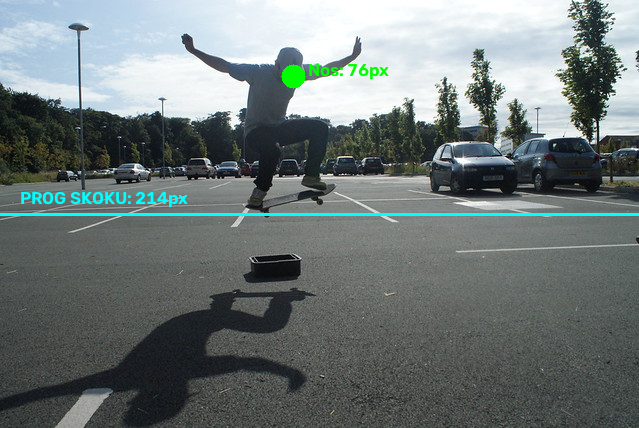

In [57]:
from PIL import Image

# Indeksy punktów
NOSE = 0

# Wybieramy pierwsze zdjęcie: skateboard.jpg
res = results_pose[0]
frame = res.orig_img.copy()
h, w, _ = frame.shape

# Pozioma linia progu (np. 50% wysokości kadru)
TRIGGER_LINE_Y = int(h * 0.50)

# Pobieramy punkty jedynej osoby w kadrze
points = res.keypoints.xy[0].tolist()
confs = res.keypoints.conf[0].tolist()

if confs[NOSE] > 0.5:
    nx, ny = int(points[NOSE][0]), int(points[NOSE][1])

    # Kropka: Czerwona (pod linią - kucnięcie) lub Zielona (nad linią - spoczynek)
    kolor_bgr = (0, 0, 255) if ny > TRIGGER_LINE_Y else (0, 255, 0)

    cv2.circle(frame, (nx, ny), 12, kolor_bgr, -1)
    cv2.putText(
        frame,
        f"Nos: {ny}px",
        (nx + 15, ny),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        kolor_bgr,
        2,
    )

# Rysujemy linię progu
cv2.line(frame, (0, TRIGGER_LINE_Y), (w, TRIGGER_LINE_Y), (255, 255, 0), 2)
cv2.putText(
    frame,
    f"PROG SKOKU: {TRIGGER_LINE_Y}px",
    (20, TRIGGER_LINE_Y - 10),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (255, 255, 0),
    2,
)

Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

### Zadanie: Logika kontrolera gry

Przed podpięciem gry musimy zamienić współrzędne punktów na prostą decyzję logiczną (`True` lub `False`).

Wybierz **jeden** z wariantów sterowania i uzupełnij brakujący warunek logiczny w kodzie poniżej:
* **Wariant A (Przysiad):** Czy nos znalazł się poniżej linii progu?
* **Wariant B (Podniesienie ręki):** Czy prawy nadgarstek znajduje się wyżej na ekranie niż prawy bark? (Pamiętaj o odwróconej osi Y: wyżej = mniejszy $y$).
* **Wariant C (Złączenie dłoni / Klaśnięcie):** Czy odległość euklidesowa między nadgarstkami jest mniejsza niż 60 pikseli?
  $$d = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

In [58]:
import math

NOSE = 0
RIGHT_SHOULDER = 6
RIGHT_WRIST = 10
LEFT_WRIST = 9


def sprawdz_skok(res, trigger_y=300):
    """Funkcja analizuje klatkę i zwraca True (skok) lub False (brak akcji)."""
    points = res.keypoints.xy[0].tolist()

    nos_y = points[NOSE][1]
    prawy_bark_y = points[RIGHT_SHOULDER][1]
    prawy_nadgarstek_y = points[RIGHT_WRIST][1]

    # === WYBIERZ JEDEN WARUNEK ===
    # Wariant A (przysiad):
    decyzja = nos_y > trigger_y

    # Wariant B (ręka w górze - odwrócona oś Y!):
    # decyzja = prawy_nadgarstek_y < prawy_bark_y

    return decyzja, nos_y


# Testujemy oba zdjęcia w pętli
for res, sciezka in zip(results_pose, sciezki):
    nazwa = sciezka.split("/")[-1]
    h = res.orig_img.shape[0]

    skok, pozycja_nosa = sprawdz_skok(res, trigger_y=int(h * 0.5))

    komunikat = ">>> AKCJA: SKOK! <<<" if skok else "--- BRAK AKCJI ---"
    print(f"[{nazwa}] Nos Y: {int(pozycja_nosa)}px -> {komunikat}")

[skateboard.jpg] Nos Y: 76px -> --- BRAK AKCJI ---
[baseball_1guy.jpg] Nos Y: 119px -> --- BRAK AKCJI ---


Dystans dłoni: 155.1 px | Decyzja: Dlonie rozdzielone


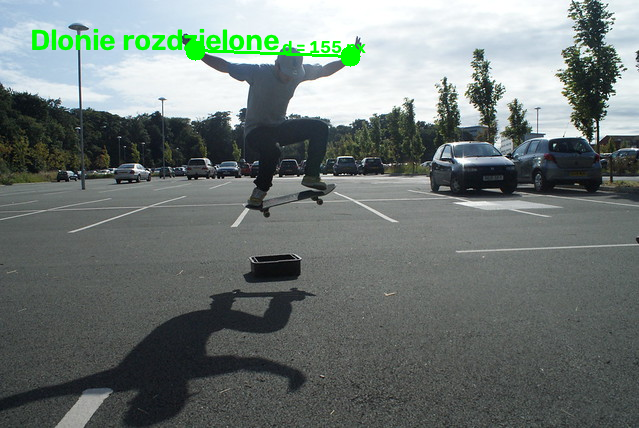

In [59]:
import math
import cv2
from PIL import Image

# 1. Indeksy punktów COCO dla nadgarstków
LEFT_WRIST = 9
RIGHT_WRIST = 10
KLASNIECIE_PROG = 70  # Maksymalny dystans w pikselach uznawany za złączenie dłoni

# 2. Pobieramy wyniki i kopię klatki
res = results_pose[0]
frame = res.orig_img.copy()

points = res.keypoints.xy[0].tolist()
confs = res.keypoints.conf[0].tolist()

# Pobieramy współrzędne i pewność obu dłoni
p_lewa = points[LEFT_WRIST]
p_prawa = points[RIGHT_WRIST]
conf_lewa = confs[LEFT_WRIST]
conf_prawa = confs[RIGHT_WRIST]

# 3. Sprawdzamy, czy model widzi obie dłonie
if conf_lewa > 0.5 and conf_prawa > 0.5:
    x_l, y_l = int(p_lewa[0]), int(p_lewa[1])
    x_p, y_p = int(p_prawa[0]), int(p_prawa[1])

    # Obliczenie odległości euklidesowej
    dystans = math.dist((x_l, y_l), (x_p, y_p))

    # Warunek logiczny
    jest_klasniecie = dystans < KLASNIECIE_PROG

    # Wizualizacja: linia łącząca dłonie zmienia kolor na czerwony przy klaśnięciu
    kolor_bgr = (0, 0, 255) if jest_klasniecie else (0, 255, 0)
    tekst_akcji = "KLASNIECIE -> SKOK!" if jest_klasniecie else "Dlonie rozdzielone"

    # Rysujemy punkty na dłoniach i linię dystansu między nimi
    cv2.circle(frame, (x_l, y_l), 10, kolor_bgr, -1)
    cv2.circle(frame, (x_p, y_p), 10, kolor_bgr, -1)
    cv2.line(frame, (x_l, y_l), (x_p, y_p), kolor_bgr, 2)

    # Wypisujemy odległość na środku linii łączącej dłonie
    srodek_x, srodek_y = (x_l + x_p) // 2, (y_l + y_p) // 2
    cv2.putText(
        frame,
        f"d = {int(dystans)} px",
        (srodek_x + 10, srodek_y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        kolor_bgr,
        2,
    )

    # Informacja o stanie gry w rogu ekranu
    cv2.putText(
        frame,
        tekst_akcji,
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        kolor_bgr,
        3,
    )
    print(f"Dystans dłoni: {dystans:.1f} px | Decyzja: {tekst_akcji}")
else:
    print("Model nie widzi obu dłoni z wystarczającą pewnością.")

# 4. Wyświetlenie obrazu w komórce notebooka
Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))